← [10 - Cryptarithmes](Z3-Python-10-Cryptarithmetic.ipynb) | [README Z3-Python](README.md)

# 11. Coloration de graphe : le graphe de Petersen

La **coloration de graphe** consiste a attribuer une couleur a chaque sommet telle que deux sommets relies par une arete portent des couleurs differentes. Le **nombre chromatique** `chi(G)` est le nombre minimal de couleurs necessaires. Probleme **NP-complet** : il n'existe pas d'algorithme polynomial connu pour le resoudre en general.

Le **graphe de Petersen** (10 sommets, 15 aretes) est un cas canonique : son nombre chromatique est `chi = 3` (ni biparti `chi=2`, ni trivial). La **recherche lineaire sur k** combinee a Z3 ne se contente pas de *trouver* 3 couleurs - elle **prouve** que 2 sont impossibles (`unsat`), ce qu'une heuristique gloutonne ne peut jamis affirmer.

> Port pyz3 du notebook C# [`12_Graph_Coloring_Petersen.ipynb`](../Z3/12_Graph_Coloring_Petersen.ipynb). EPIC #1206, Prong B. (La section B2 MkIte du C#, specifique au DSL Z3.Linq, n'est pas portee.)

In [1]:
from z3 import *
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
plt.ioff()  # batch mode
print("Imports OK : z3-solver, matplotlib")


Imports OK : z3-solver, matplotlib


## 1. Le graphe de Petersen

Le graphe de Petersen a 10 sommets (0 a 9) et 15 aretes organisees en trois structures : le **pentagone externe** (0-1-2-3-4-0), les **rayons** (0-5, 1-6, ...) et le **pentagramme interne** (5-7-9-6-8-5). C'est un exemple celebre en theorie des graphes : 3-regulier, non hamiltonien, et son nombre chromatique est exactement 3.

In [2]:
# Graphe de Petersen : 10 sommets (0..9), 15 aretes
N = 10
edges = [
    # Pentagone externe
    (0,1),(1,2),(2,3),(3,4),(4,0),
    # Rayons externe -> interne
    (0,5),(1,6),(2,7),(3,8),(4,9),
    # Pentagramme interne
    (5,7),(7,9),(9,6),(6,8),(8,5),
]

# Liste d'adjacence (pour le glouton)
adj = {v: [] for v in range(N)}
for a, b in edges:
    adj[a].append(b); adj[b].append(a)

def display_coloring(color, title):
    print(title)
    k = max(color) + 1
    print("  Couleurs utilisees : %d" % k)
    for v in range(len(color)):
        print("  Sommet %d -> couleur %d" % (v, color[v]))
    valid = all(color[a] != color[b] for a, b in edges)
    print("  Coloration valide (aucune arete monochrome) : %s" % valid)

print("Graphe de Petersen charge : %d sommets, %d aretes." % (N, len(edges)))


Graphe de Petersen charge : 10 sommets, 15 aretes.


## 2. Approche 1 : heuristique gloutonne (first-fit)

L'heuristique **first-fit** parcourt les sommets dans un ordre donne et assigne a chacun la plus petite couleur non utilisee par ses voisins deja colores. Simple et rapide, mais **le resultat depend de l'ordre** : un ordre defavorable gaspille des couleurs. Et surtout, le glouton ne peut jamais **prouver** qu'il a atteint l'optimum - il ne fait que constater ce qu'il a trouve.

In [3]:
# Coloration gloutonne first-fit selon un ordre de parcours donne
def greedy_coloring(n, adjacency, order):
    color = [-1] * n
    for v in order:
        used = set()
        for w in adjacency[v]:
            if color[w] != -1:
                used.add(color[w])
        c = 0
        while c in used:
            c += 1
        color[v] = c
    return color

# Ordre naturel 0..9
natural_order = list(range(N))
greedy_natural = greedy_coloring(N, adj, natural_order)
greedy_natural_colors = max(greedy_natural) + 1
display_coloring(greedy_natural, "First-fit, ordre naturel 0..9 :")
print()

# Ordre defavorable (force la 4e couleur)
bad_order = [4, 8, 2, 6, 5, 9, 0, 7, 1, 3]
greedy_bad = greedy_coloring(N, adj, bad_order)
greedy_bad_colors = max(greedy_bad) + 1
display_coloring(greedy_bad, "First-fit, ordre defavorable %s :" % bad_order)
print()
print("Meme graphe, meme algorithme : %d couleurs vs %d couleurs selon l'ordre." % (greedy_natural_colors, greedy_bad_colors))


First-fit, ordre naturel 0..9 :
  Couleurs utilisees : 3
  Sommet 0 -> couleur 0
  Sommet 1 -> couleur 1
  Sommet 2 -> couleur 0
  Sommet 3 -> couleur 1
  Sommet 4 -> couleur 2
  Sommet 5 -> couleur 1
  Sommet 6 -> couleur 0
  Sommet 7 -> couleur 2
  Sommet 8 -> couleur 2
  Sommet 9 -> couleur 1
  Coloration valide (aucune arete monochrome) : True

First-fit, ordre defavorable [4, 8, 2, 6, 5, 9, 0, 7, 1, 3] :
  Couleurs utilisees : 4
  Sommet 0 -> couleur 2
  Sommet 1 -> couleur 3
  Sommet 2 -> couleur 0
  Sommet 3 -> couleur 1
  Sommet 4 -> couleur 0
  Sommet 5 -> couleur 1
  Sommet 6 -> couleur 1
  Sommet 7 -> couleur 3
  Sommet 8 -> couleur 0
  Sommet 9 -> couleur 2
  Coloration valide (aucune arete monochrome) : True

Meme graphe, meme algorithme : 3 couleurs vs 4 couleurs selon l'ordre.


## Interpretation

Le glouton trouve **3 couleurs** dans le bon ordre mais **4 dans l'ordre defavorable** - alors que l'optimum est toujours 3. C'est le piege des heuristiques : sans recherche exhaustive, impossible de savoir si le resultat est optimal. Le solveur, lui, va **prouver** l'optimalite.

## 3. Approche 2 : modelisation Z3

On encode une variable entiere `C_v` par sommet (couleur de v), on borne les couleurs a `[0, k)`, on fixe `C_0 = 0` (brisure de symetrie - evite l'explosion par permutation de couleurs), et pour chaque arete `(a,b)` on impose `C_a != C_b`.

In [4]:
# Modele Z3 : une variable de couleur par sommet
Color = [Int('C%d' % v) for v in range(N)]
print("Modele defini : %d variables de couleur entieres C0..C9." % N)


Modele defini : 10 variables de couleur entieres C0..C9.


## 4. Recherche du nombre chromatique

On cherche le plus petit `k` tel que le graphe soit `k`-colorable. Pour chaque `k`, on instancie le modele (domaine `[0,k)`, brisure de symetrie, contraintes d'aretes) et on teste la **satisfiabilite** :
- `sat` -> `k` couleurs suffisent, le nombre chromatique est `k` (car les `k-1` precedents etaient `unsat`).

- `unsat` -> `k` couleurs ne suffisent pas, on essaie `k+1`.



C'est cette double nature (trouver ET prouver l'impossibilite) qui fait la force du solveur face au glouton.

In [5]:
# Recherche lineaire du nombre chromatique
optimal_color = None
chromatic = -1

for k in range(1, N + 1):
    s = Solver()
    s.add([And(Color[v] >= 0, Color[v] < k) for v in range(N)])
    # Brisure de symetrie : la couleur du sommet 0 est fixee
    s.add(Color[0] == 0)
    # Aretes : extremites de couleurs differentes
    for a, b in edges:
        s.add(Color[a] != Color[b])
    if s.check() == sat:
        m = s.model()
        optimal_color = [m[Color[v]].as_long() for v in range(N)]
        chromatic = k
        print("k = %d -> SAT : nombre chromatique trouve !" % k)
        break
    else:
        print("k = %d -> UNSAT (impossible avec %d couleur(s))" % (k, k))

print()
print("Nombre chromatique chi(Petersen) = %d" % chromatic)


k = 1 -> UNSAT (impossible avec 1 couleur(s))
k = 2 -> UNSAT (impossible avec 2 couleur(s))
k = 3 -> SAT : nombre chromatique trouve !

Nombre chromatique chi(Petersen) = 3


## Interpretation : `chi = 3` prouve

Z3 confirme `chi(Petersen) = 3` : `k=1` et `k=2` sont `unsat` (preuve qu'on ne peut pas faire mieux), `k=3` est `sat` (une coloration existe). Le verdict `unsat` pour `k=2` est la **preuve formelle** que le graphe n'est pas biparti - quelque chose qu'aucune heuristique gloutonne ne peut etablir.

In [6]:
# Extraction et verification de la coloration optimale
display_coloring(optimal_color, "Coloration optimale Z3 (chi = %d) :" % chromatic)
print()
print("=== Comparaison ===")
print("  Glouton first-fit (ordre naturel)    : %d couleurs" % greedy_natural_colors)
print("  Glouton first-fit (ordre defavorable): %d couleurs" % greedy_bad_colors)
print("  Z3 (optimum PROUVE)                  : %d couleurs" % chromatic)
print("  Dans le pire ordre, le glouton gaspille %d couleur(s)." % (greedy_bad_colors - chromatic))
print("  Surtout : seul Z3 PROUVE que %d est minimal (2 couleurs = UNSAT)." % chromatic)


Coloration optimale Z3 (chi = 3) :
  Couleurs utilisees : 3
  Sommet 0 -> couleur 0
  Sommet 1 -> couleur 1
  Sommet 2 -> couleur 2
  Sommet 3 -> couleur 0
  Sommet 4 -> couleur 1
  Sommet 5 -> couleur 1
  Sommet 6 -> couleur 0
  Sommet 7 -> couleur 0
  Sommet 8 -> couleur 2
  Sommet 9 -> couleur 2
  Coloration valide (aucune arete monochrome) : True

=== Comparaison ===
  Glouton first-fit (ordre naturel)    : 3 couleurs
  Glouton first-fit (ordre defavorable): 4 couleurs
  Z3 (optimum PROUVE)                  : 3 couleurs
  Dans le pire ordre, le glouton gaspille 1 couleur(s).
  Surtout : seul Z3 PROUVE que 3 est minimal (2 couleurs = UNSAT).


## Visualisation : la coloration optimale

Le graphe de Petersen se dessine classiquement avec un pentagone externe, un pentagramme interne et 5 rayons. La coloration a 3 couleurs (une par cercle) rend visible l'absence d'arete monochrome.

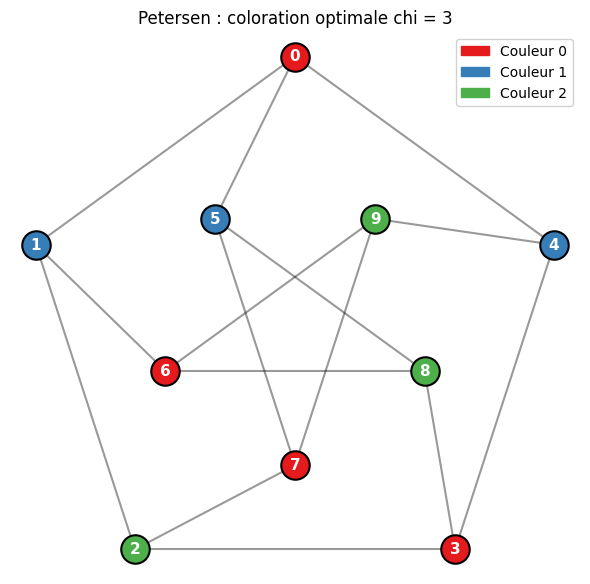

In [7]:
# Visualisation de la coloration 3-chromatique du graphe de Petersen
import math
# Positions canoniques : pentagone externe + pentagramme interne
pos = {}
for i in range(5):
    ang = math.pi/2 + 2*math.pi*i/5
    pos[i] = (2.0*math.cos(ang), 2.0*math.sin(ang))           # externe (rayon 2)
    ang2 = math.pi/2 + 2*math.pi*i/5 + math.pi/5               # interne decale
    pos[5+i] = (1.0*math.cos(ang2), 1.0*math.sin(ang2))        # interne (rayon 1)

palette = ['#e41a1c', '#377eb8', '#4daf4a']  # rouge / bleu / vert

fig, ax = plt.subplots(figsize=(6, 6))
for a, b in edges:
    x = [pos[a][0], pos[b][0]]; y = [pos[a][1], pos[b][1]]
    ax.plot(x, y, 'k-', alpha=0.4, zorder=1)
for v in range(N):
    ax.scatter(*pos[v], c=palette[optimal_color[v]], s=420, edgecolors='black',
               linewidths=1.5, zorder=2)
    ax.annotate(str(v), pos[v], ha='center', va='center', color='white',
                fontsize=11, fontweight='bold', zorder=3)
ax.set_title("Petersen : coloration optimale chi = %d" % chromatic)
ax.set_aspect('equal'); ax.axis('off')
handles = [mpatches.Patch(color=palette[c], label='Couleur %d' % c) for c in range(chromatic)]
ax.legend(handles=handles, loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()


## 5. Glouton vs solveur : ce que demontre Petersen

Le graphe de Petersen illustre trois lecons :
1. **L'heuristique est sensible a l'ordre** - 3 ou 4 couleurs selon comment on parcourt les sommets, pour le meme graphe.

2. **Seul le solveur prouve l'optimalite** - le `unsat` a `k=2` est une preuve formelle d'impossibilite, pas un constat d'echec.

3. **La recherche lineaire sur k est efficace** - on ne resout pas un seul gros probleme mais une suite de decisions `sat`/`unsat`, chacune rapide par propagation.

## Exercices

Les trois exercices ci-dessous generalisent la coloration a des variantes : forcer un nombre chromatique plus eleve (1), appliquer la coloration a un probleme concret de planification (2), et enumerer toutes les colorations possibles (3). Chaque stub est self-contained : les fonctions utilitaires (`edges`, `adj`, modele Z3) sont definies dans les sections precedentes.

### Exercice 1 - Forcer une quatrieme couleur

Ajoutez une arete au graphe de Petersen de maniere a creer une **clique de taille 4** (4 sommets tous relies deux a deux), puis recalculez le nombre chromatique. Une clique de taille `n` impose `chi >= n` (chaque sommet d'une clique doit avoir une couleur distincte).



**Etapes** : choisir 4 sommets, lister les aretes manquantes pour qu'ils forment une clique, construire un nouveau modele avec les aretes supplementaires, relancer la recherche lineaire et verifier `chi == 4`.

In [8]:
# Exercice 1 : ajouter une arete creant une clique de taille 4, recalculer chi
# TODO etudiant :
# Etape 1 : choisir 4 sommets et lister les aretes a ajouter pour qu'ils forment une clique
# Etape 2 : construire un nouveau modele avec les aretes supplementaires
# Etape 3 : relancer la recherche lineaire et verifier chi == 4
result = None  # TODO etudiant
print("Exercice 1 a completer : forcez chi = 4 en ajoutant une clique de taille 4")


Exercice 1 a completer : forcez chi = 4 en ajoutant une clique de taille 4


### Exercice 2 - Planification d'examens

La planification d'examens est une **coloration deguisee** : les sommets sont les examens, les aretes relient deux examens partageant au moins un etudiant (conflit), et les couleurs sont les creneaux horaires. Le nombre chromatique donne le nombre minimal de creneaux sans conflit.



**Etapes** : definir un graphe de conflits (5-6 examens avec des chevauchements d'etudiants), trouver le nombre minimal de creneaux via la recherche lineaire, afficher l'emploi du temps par creneau.

In [9]:
# Exercice 2 : planification d'examens (coloration deguisee)
# TODO etudiant :
# Etape 1 : definir votre graphe de conflits (sommets = examens, aretes = etudiants communs)
# Etape 2 : trouver le nombre minimal de creneaux via la recherche lineaire
# Etape 3 : afficher l'emploi du temps par creneau
result = None  # TODO etudiant
print("Exercice 2 a completer : planifiez les examens par coloration de graphe")


Exercice 2 a completer : planifiez les examens par coloration de graphe


### Exercice 3 - Compter les 3-colorations

Combien de colorations distinctes a 3 couleurs admet le graphe de Petersen ? On enumere les solutions en ajoutant a chaque fois une contrainte d'exclusion de la solution trouvee, jusqu'a `unsat`.



**Etapes** : boucle qui resout, compte la solution, puis l'exclut (`Or(C[v] != sol[v])`) jusqu'a `unsat` ; comparer au resultat attendu **120** ; diviser par `3! = 6` pour obtenir le nombre de colorations a permutation de couleurs pres.

In [10]:
# Exercice 3 : compter les 3-colorations en enumerant les solutions
# TODO etudiant :
# Etape 1 : boucle qui resout, puis exclut la solution trouvee, jusqu'a UNSAT
# Etape 2 : compter les solutions ; comparer a 120
# Etape 3 : diviser par 3! = 6 pour obtenir les colorations a permutation pres
nb_colorations = None  # TODO etudiant
print("Exercice 3 a completer : enumerez les 3-colorations (attendu : 120 total, 20 a permutation pres)")


Exercice 3 a completer : enumerez les 3-colorations (attendu : 120 total, 20 a permutation pres)


## Conclusion

La coloration de graphe cristallise la difference entre **heuristique** et **preuve**. Le glouton first-fit est rapide mais myope : il offre 3 ou 4 couleurs selon l'ordre, sans jamais certifier l'optimum. Z3, par la **recherche lineaire sur k** combinee aux verdicts `sat`/`unsat`, trouve le nombre chromatique `chi = 3` **et prouve qu'il est minimal** (`k=2` unsat).



Cette double capacity - trouver une solution **et** certifier l'impossibilite de faire mieux - est le coeur de l'apport SMT. Elle se generalize a tous les problemes d'optimisation combinatoire ou l'on veut non pas une bonne solution, mais la **meilleure prouvee**.